In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivvm/sleep-stages-dataset/sleep_stage_dataset.pkl


In [158]:
import pickle
with open("/kaggle/input/datasets/shivvm/sleep-stages-dataset/sleep_stage_dataset.pkl","rb") as f:
    dataset = pickle.load(f)
signals = dataset['signals']
window_time = dataset['window_time']
labels = dataset['labels']
participant_ids =dataset['participants']
    

In [79]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt


In [80]:
print(signals.shape)
print(labels.shape)

(8800, 960)
(8800,)


In [81]:
np.unique(labels)

array(['Body event', 'Hypopnea', 'Mixed Apnea', 'Normal',
       'Obstructive Apnea'], dtype='<U32')

In [83]:
signals = signals.reshape(8800,960,-1)
y_labels = y_labels.reshape(8800,-1)

In [148]:
pd.Series(labels).value_counts()

Normal               8038
Hypopnea              593
Obstructive Apnea     164
Body event              3
Mixed Apnea             2
Name: count, dtype: int64

In [160]:
for i in range(len(labels)):
    if labels[i]=="Body event":
        labels[i]="Normal"
    elif labels[i]=="Mixed Apnea":
        labels[i]="Hypopnea"
    else:
        continue
print(np.unique(labels))
label_map = {'Normal':0, 'Hypopnea':1, 'Obstructive Apnea':2}
y_labels = np.array([label_map[label] for label in labels])
print(y_labels)
signals = signals.reshape(8800,960,-1)
y_labels = y_labels.reshape(8800,-1)


['Hypopnea' 'Normal' 'Obstructive Apnea']
[0 0 0 ... 0 0 0]


In [217]:
from tensorflow.keras import Sequential, layers,regularizers
from tensorflow.keras.metrics import Recall
from sklearn.metrics import recall_score



def build_model():
    model = Sequential([
        layers.Conv1D(32, 3, activation='relu', input_shape=(960,1)),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=["accuracy"])
    return model

In [162]:
signals.shape

(8800, 960, 1)

In [180]:
y_labels

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [218]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight



X=signals
y = y_labels
# normalize per window
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

unique_participants = np.unique(participant_ids)
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_cms = []

for test_pid in unique_participants:
    train_idx = np.where(participant_ids != test_pid)[0]
    test_idx  = np.where(participant_ids == test_pid)[0]
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    print(X_train.shape)  # should be (num_samples, 960, 1)
    print(X_test.shape)
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train.ravel())
    class_weights = dict(zip(classes, class_weights))
    model = build_model()  # reinitialize CNN for each fold
    print(classes)
    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        verbose=1,
        class_weight=class_weights
    )
    
    # Evaluate metrics
    y_pred_probs = model.predict(X_test)
    
    # Store accuracy, precision, recall, confusion matrix per fold
    # y_pred = np.argmax(y_pred_probs, axis=-1)
    y_pred = y_pred_probs.argmax(axis=1)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred,labels=classes)
    
    # Store metrics for this fold
    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_cms.append(cm)
    
    print(f"Fold Test Participant {test_pid}  Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}")

(6978, 960, 1)
(1822, 960, 1)
[0 1 2]
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3803 - loss: 1.1951
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6464 - loss: 1.0004
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6380 - loss: 0.9453
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7029 - loss: 0.8707
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6672 - loss: 0.8844
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7485 - loss: 0.8720
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7049 - loss: 0.8342
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7266 - loss: 0.8917
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7478 - loss: 0.8809
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6650 - loss: 0.9258
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Fold Test Participant AP01  Accuracy: 0.888, Precision: 0.391, Recall: 0.456
(7031, 960, 1)
(1769, 960, 1)
[0 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2805 - loss: 1.2648
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6830 - loss: 0.9207
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7200 - loss: 0.8899
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6416 - loss: 0.8735
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6336 - loss: 0.8946
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6866 - loss: 0.8871
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7329 - loss: 0.8303
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6416 - loss: 0.8267
Epoch 9/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7089 - loss: 0.8230
Epoch 10/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6944 - loss: 0.7879
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Fold Test Participant AP02  Accuracy: 0.777, Precision: 0.373, Recall: 0.485
(7104, 960, 1)
(1696, 960, 1)
[0 

...

222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5129 - loss: 1.2038
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5705 - loss: 0.9592
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6930 - loss: 0.8720
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7217 - loss: 0.8556
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7089 - loss: 0.8480
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7047 - loss: 0.8489
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7295 - loss: 0.8132
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7006 - loss: 0.8073
Epoch 9/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7119 - loss: 0.8463
Epoch 10/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7490 - loss: 0.7797
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold Test Participant AP03  Accuracy: 0.801, Precision: 0.335, Recall: 0.352
(6868, 960, 1)
(1932, 960, 1)
[0 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


215/215 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5614 - loss: 1.2001
Epoch 2/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6993 - loss: 1.0071
Epoch 3/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6011 - loss: 0.9525
Epoch 4/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7241 - loss: 0.8865
Epoch 5/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7726 - loss: 0.8473
Epoch 6/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6980 - loss: 0.8799
Epoch 7/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7121 - loss: 0.8804
Epoch 8/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7171 - loss: 0.8282
Epoch 9/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7085 - loss: 0.9251
Epoch 10/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7215 - loss: 0.8931
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Fold Test Participant AP04  Accuracy: 0.719, Precision: 0.355, Recall: 0.692
(7219, 960, 1)
(1581, 960, 1)
[0 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5365 - loss: 1.7594
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6274 - loss: 1.1953
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2548 - loss: 1.2331
Epoch 4/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2070 - loss: 1.3076
Epoch 5/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3895 - loss: 1.0165
Epoch 6/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3497 - loss: 1.0097
Epoch 7/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4080 - loss: 0.9306
Epoch 8/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5534 - loss: 0.8782
Epoch 9/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6380 - loss: 0.8519
Epoch 10/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5963 - loss: 0.7560
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Fold Test Participant AP05  Accuracy: 0.670, Precision: 0.402, Recall: 0.445


In [219]:
print("\n--- LOPO CV Results ---")
print("Average Accuracy:", np.mean(fold_accuracies))
print("Average Precision:", np.mean(fold_precisions))
print("Average Recall:", np.mean(fold_recalls))
print("Average F1-Score:", np.mean(fold_f1s))


--- LOPO CV Results ---
Average Accuracy: 0.771084760528354
Average Precision: 0.37122015102979733
Average Recall: 0.48597960572885956
Average F1-Score: 0.3675901908118793


Participant 1 



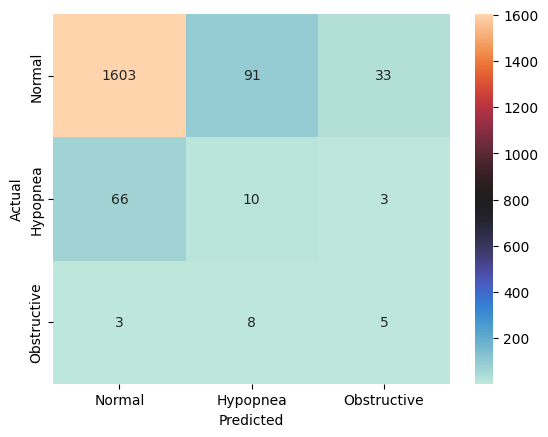

Participant 2 



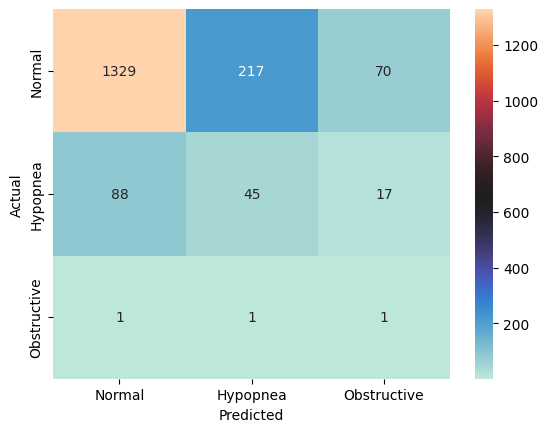

Participant 3 



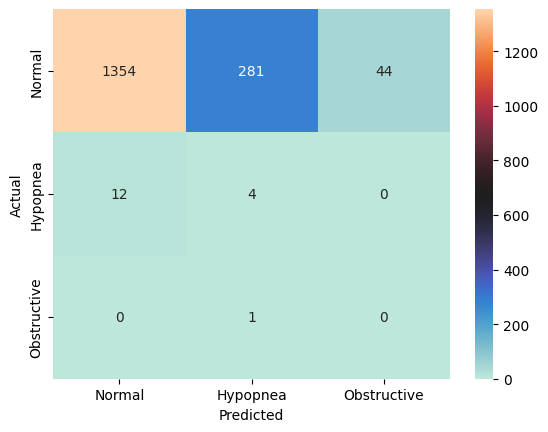

Participant 4 



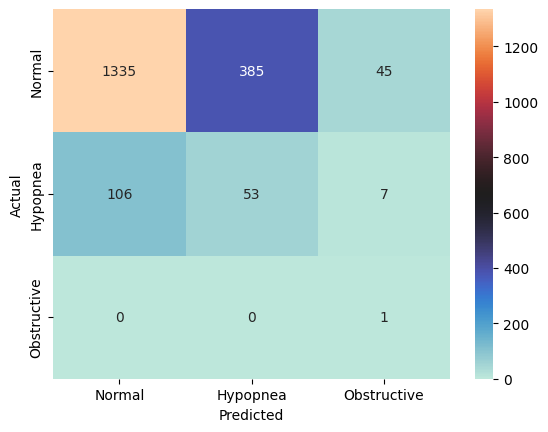

Participant 5 



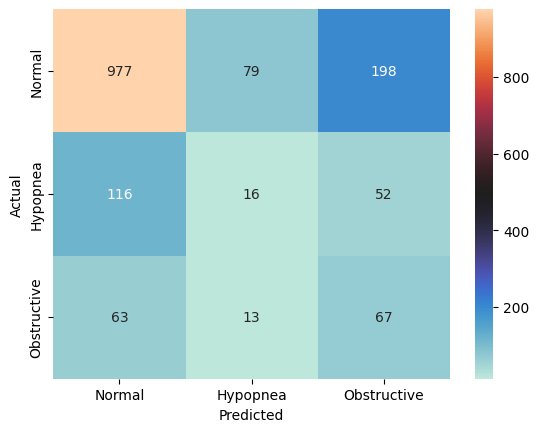

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt
for i in range(len(fold_cms)):
    print(f"Participant {i+1} \n")
    sns.heatmap(fold_cms[i], annot=True, fmt="d", xticklabels=["Normal","Hypopnea","Obstructive"], yticklabels=["Normal","Hypopnea","Obstructive"],cmap="icefire")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
